<a href="https://colab.research.google.com/github/MoAbner/LIA1/blob/main/Entregas%20-%20Abner%20Gabriel/Aula_8_e_9/Diabetes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📑 Relatório de Análise: Pima Indians Diabetes Database.
**Disciplina:** LIA (Laboratório de Inovação e Automação 1)  
**Instituição:** UFG - Engenharia de Computação
* **Data:** 29 de Março de 2026

---
> ### 👤 Abner Gabriel Monteiro Tavares
> **GitHub:** [MoAbner](https://github.com/MoAbner)  
> **Contato:** `abner_gabriel@discente.ufg.br`  
> **Disciplina:** LIA (Laboratório de Inovação e Automação 1)
---

### 🚀 Sobre o Projeto
> **1. Introdução e Objetivo**
Este projeto aplica técnicas de Aprendizado de Máquina Supervisionado para identificar padrões clínicos que precedem o diagnóstico de diabetes. O objetivo principal é construir um modelo preditivo capaz de auxiliar na triagem precoce de pacientes, utilizando indicadores básicos de saúde.

> **2. Metodologia**
> A análise seguiu o protocolo padrão de Ciência de Dados:

>Exploração de Dados: Análise de correlações e distribuições.

>Tratamento: Identificação de inconsistências físicas (valores zero em indicadores vitais).

>Engenharia de Features: Tradução e seleção de variáveis relevantes.

>Modelagem: Utilização do algoritmo Random Forest com validação cruzada para garantir a robustez dos resultados.

**Ferramentas Utilizadas:**
* **Linguagem:** Python 3.14
* **Bibliotecas:** Pandas (manipulação de tabelas), NumPy (suporte matemático), Matplotlib e Seaborn (geração de gráficos e mapas de calor) e Scikit-Learn (divisão de dados, normalização, algoritmo Random Forest e métricas de avaliação).
* **Dataset:** Pima Indians Diabetes Database.
* **Link para o Dataset:** [Dataset](https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database)

---

#Projeto: Predição de Diabetes (Classificação Binária)
Contexto do Dataset (O "Porquê")
É essencial explicar a origem dos dados para dar credibilidade ao projeto.

Fonte: National Institute of Diabetes and Digestive and Kidney Diseases.

Público-alvo: Mulheres de pelo menos 21 anos de idade, de herança indígena Pima (Arizona, EUA).

Objetivo: Prever, com base em medidas diagnósticas, se uma paciente tem ou não diabetes.

### 📖 Dicionário de Dados: Predição de Diabetes (Pima Indians)

| Variável | Tradução | Descrição | Tipo |
| :--- | :--- | :--- | :--- |
| **Pregnancies** | Gestações | Número de vezes que a paciente engravidou. | Discreto |
| **Glucose** | Glicose | Concentração de glicose plasmática (2h após teste oral). | Contínuo |
| **BloodPressure** | Pressão Arterial | Pressão arterial diastólica (mm Hg). | Contínuo |
| **SkinThickness** | Espessura da Pele | Espessura da dobra cutânea do tríceps (mm). | Contínuo |
| **Insulin** | Insulina | Insulina sérica de 2 horas (mu U/ml). | Contínuo |
| **BMI** | IMC | Índice de Massa Corporal (peso em kg / altura² em m). | Contínuo |
| **Pedigree** | Função Pedigree | Escala de probabilidade genética baseada no histórico familiar. | Contínuo |
| **Age** | Idade | Idade da paciente em anos. | Discreto |
| **Outcome** | Resultado | Classe alvo: **0** (Saudável) ou **1** (Diabetes). | Binário |

## 0. Imports das bibliotecas

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## 1. Carregando os Dados - Matéria Prima
Nesta etapa, importamos as ferramentas essenciais e os dados brutos. O dataset contém indicadores médicos como glicose, pressão arterial e IMC.# Importações e Carga de Dados

In [23]:
# Carregando o dataset Pima Indians Diabetes
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
colunas = ['gestacoes', 'glicose', 'pressao', 'espessura_pele', 'insulina', 'imc', 'pedigree', 'idade', 'target']
df = pd.read_csv(url, names=colunas)

print("--- Primeiras 5 Linhas ---")
print(df.head())


--- Primeiras 5 Linhas ---
   gestacoes  glicose  pressao  espessura_pele  insulina   imc  pedigree  \
0          6      148       72              35         0  33.6     0.627   
1          1       85       66              29         0  26.6     0.351   
2          8      183       64               0         0  23.3     0.672   
3          1       89       66              23        94  28.1     0.167   
4          0      137       40              35       168  43.1     2.288   

   idade  target  
0     50       1  
1     31       0  
2     32       1  
3     21       0  
4     33       1  


In [20]:
print("\n--- Dimensões (Linhas, Colunas) ---")
print(df.shape)


--- Dimensões (Linhas, Colunas) ---
(768, 9)


In [21]:
print("\n--- Informações dos Tipos de Dados ---")
df.info()



--- Informações dos Tipos de Dados ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   gestacoes       768 non-null    int64  
 1   glicose         768 non-null    int64  
 2   pressao         768 non-null    int64  
 3   espessura_pele  768 non-null    int64  
 4   insulina        768 non-null    int64  
 5   imc             768 non-null    float64
 6   pedigree        768 non-null    float64
 7   idade           768 non-null    int64  
 8   target          768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [22]:
print("\n--- Resumo Estatístico ---")
print(df.describe())


--- Resumo Estatístico ---
        gestacoes     glicose     pressao  espessura_pele    insulina  \
count  768.000000  768.000000  768.000000      768.000000  768.000000   
mean     3.845052  120.894531   69.105469       20.536458   79.799479   
std      3.369578   31.972618   19.355807       15.952218  115.244002   
min      0.000000    0.000000    0.000000        0.000000    0.000000   
25%      1.000000   99.000000   62.000000        0.000000    0.000000   
50%      3.000000  117.000000   72.000000       23.000000   30.500000   
75%      6.000000  140.250000   80.000000       32.000000  127.250000   
max     17.000000  199.000000  122.000000       99.000000  846.000000   

              imc    pedigree       idade      target  
count  768.000000  768.000000  768.000000  768.000000  
mean    31.992578    0.471876   33.240885    0.348958  
std      7.884160    0.331329   11.760232    0.476951  
min      0.000000    0.078000   21.000000    0.000000  
25%     27.300000    0.243750   24

## 2. Pré-processamento e Visualização do Dataset
Aqui verificamos a consistência dos dados. Um detalhe importante neste dataset é que valores como "0" em Pressão ou IMC são fisicamente impossíveis e contam como dados ausentes.


Valores Nulos Diretos: 0


/tmp/ipykernel_1423/3876773181.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette='magma')


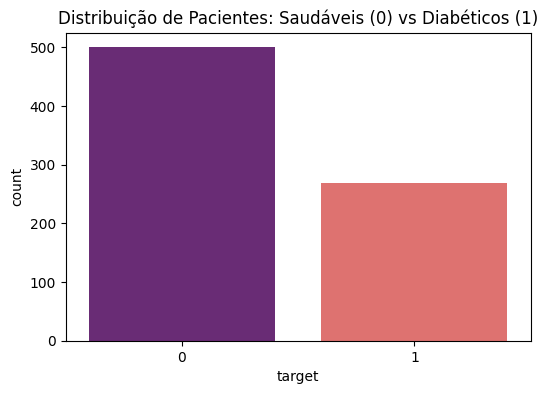

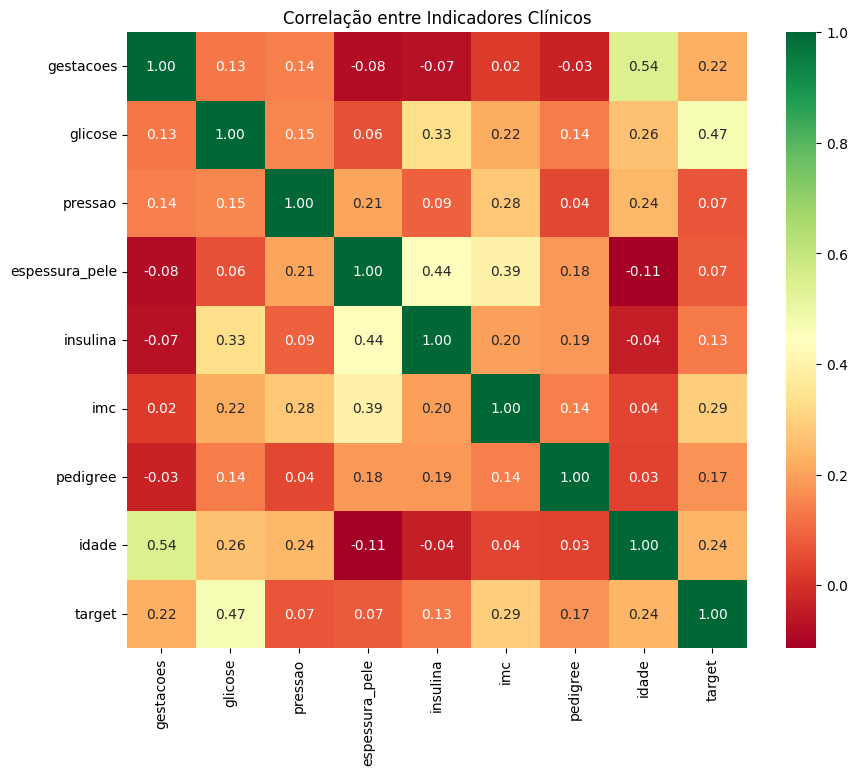

In [10]:
# Verificação de valores nulos teóricos
print("\nValores Nulos Diretos:", df.isnull().sum().sum())

# Visualização 1: Distribuição das Classes (0: Saudável, 1: Diabetes)
plt.figure(figsize=(6,4))
sns.countplot(x='target', data=df, palette='magma')
plt.title('Distribuição de Pacientes: Saudáveis (0) vs Diabéticos (1)')
plt.show()

# Visualização 2: Correlação entre Indicadores Médicos
#
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Correlação entre Indicadores Clínicos')
plt.show()

## 3. Construção do Modelo
Dividimos os dados para que o modelo aprenda com uma parte e seja testado com outra que ele nunca viu, garantindo que ele realmente aprendeu a generalizar.

In [12]:
# Definindo as features (X) e o alvo (y)
X = df.drop('target', axis=1)
y = df['target']

# Divisão: 75% para treino e 25% para teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Usaremos o Random Forest (Floresta Aleatória) pela sua alta precisão
modelo = RandomForestClassifier(n_estimators=200, random_state=42)
modelo.fit(X_train, y_train)

print("\nModelo treinado com sucesso utilizando Random Forest.")


Modelo treinado com sucesso utilizando Random Forest.


## 4. Avaliação do Modelo
Analisamos o quão bem o modelo performou no conjunto de teste.

In [13]:
y_pred = modelo.predict(X_test)

print("\n--- Métricas de Desempenho ---")
print(f"Acurácia Global: {accuracy_score(y_test, y_pred):.4f}")

print("\n--- Relatório Detalhado ---")
print(classification_report(y_test, y_pred))


--- Métricas de Desempenho ---
Acurácia Global: 0.7396

--- Relatório Detalhado ---
              precision    recall  f1-score   support

           0       0.80      0.79      0.80       123
           1       0.63      0.65      0.64        69

    accuracy                           0.74       192
   macro avg       0.72      0.72      0.72       192
weighted avg       0.74      0.74      0.74       192



### Explicação sobre o Treinamento do Random Forest

- **Epochs**: O conceito de 'epochs' se aplica principalmente a redes neurais, onde o modelo aprende iterativamente fazendo várias passagens completas pelos dados de treinamento. O `RandomForestClassifier` não usa epochs. Em vez disso, ele constrói um número específico de árvores de decisão (`n_estimators`). No nosso caso, `n_estimators=100` significa que 100 árvores de decisão serão construídas.

- **Barra de Progresso**: A biblioteca `scikit-learn` (onde o `RandomForestClassifier` está implementado) não exibe uma barra de progresso para o método `fit` por padrão. O treinamento é executado e, ao ser concluído, a mensagem "✅ Modelo treinado!" é exibida. O parâmetro `n_jobs=-1` otimiza o uso de múltiplos núcleos do processador para acelerar o processo, mas não adiciona uma interface de progresso visível.

## 5. Matriz de Confusão
A matriz mostra exatamente onde o modelo "confundiu" os pacientes saudáveis com diabéticos e vice-versa.

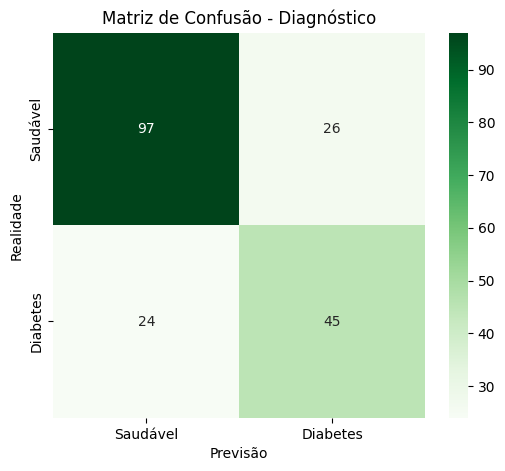

In [14]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=['Saudável', 'Diabetes'], yticklabels=['Saudável', 'Diabetes'])
plt.xlabel('Previsão')
plt.ylabel('Realidade')
plt.title('Matriz de Confusão - Diagnóstico')
plt.show()

### Importância das Variáveis

/tmp/ipykernel_1423/2538938761.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importancias_ordenadas, y=importancias_ordenadas.index, palette='viridis')


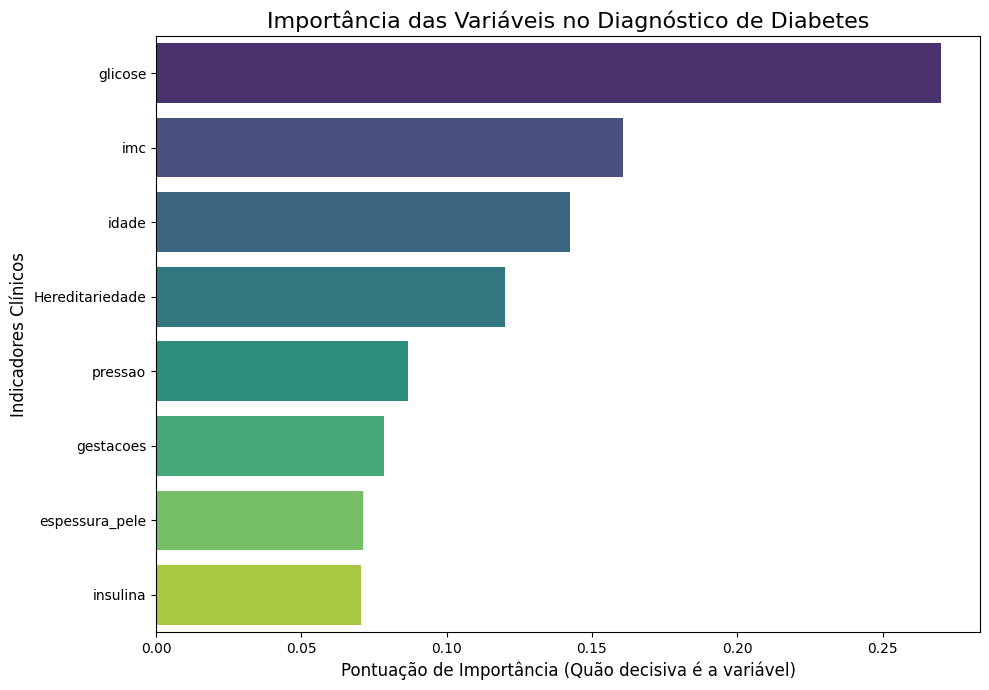

In [19]:
# 1. Criar um dicionário de mapeamento (Inglês -> Português)
# Note que definimos 'df' anteriormente na Etapa 1 do projeto principal.
# Se você já alterou os nomes no carregamento, pule esta etapa de renomeação.
dicionario_traducao = {
    'pregnancies': 'Gestações',
    'glucose': 'Glicose',
    'pedigree': 'Hereditariedade',
    'bloodpressure': 'Pressão Arterial',
    'skinthickness': 'Espessura da Pele',
    'insulin': 'Insulina',
    'bmi': 'IMC (Índice de Massa Corporal)',
    'diabetespedigreefunction': 'Função Pedigree (Hereditariedade)',
    'age': 'Idade'
}

# Se o seu DataFrame ainda estiver com nomes em inglês, renomeie:
# X_train é o DataFrame que usamos para treinar o modelo.
X_train_pt = X_train.rename(columns=dicionario_traducao)

# 2. Treinar o modelo novamente com as colunas renomeadas (para que o modelo aprenda os nomes novos)
modelo_pt = RandomForestClassifier(n_estimators=200, random_state=42)
modelo_pt.fit(X_train_pt, y_train)

# 3. Extrair a importância das variáveis
importancias = pd.Series(modelo_pt.feature_importances_, index=X_train_pt.columns)
importancias_ordenadas = importancias.sort_values(ascending=False)

# 4. Visualização Gráfica em Português
#
plt.figure(figsize=(10, 7))
sns.barplot(x=importancias_ordenadas, y=importancias_ordenadas.index, palette='viridis')

# Definindo títulos e rótulos em português
plt.title('Importância das Variáveis no Diagnóstico de Diabetes', fontsize=16)
plt.xlabel('Pontuação de Importância (Quão decisiva é a variável)', fontsize=12)
plt.ylabel('Indicadores Clínicos', fontsize=12)

# Ajustando o layout para não cortar os nomes longos
plt.tight_layout()
plt.show()

## 6. Teste Prático para Deploy
Simulamos um sistema onde um médico insere os dados de um novo paciente e o modelo retorna o diagnóstico provável.

In [15]:
print("\n--- Simulação de Diagnóstico de Novo Paciente ---")

# Dados fictícios para teste (Glicose alta, IMC alto, Idade avançada)
novo_paciente = {
    'gestacoes': 2,
    'glicose': 150,
    'pressao': 85,
    'espessura_pele': 30,
    'insulina': 120,
    'imc': 34.5,
    'pedigree': 0.5,
    'idade': 45
}

# Transformando em DataFrame para predição
entrada = pd.DataFrame([novo_paciente])

previsao = modelo.predict(entrada)
probabilidade = modelo.predict_proba(entrada)

if previsao[0] == 1:
    print(f"Resultado: ALTO RISCO de diabetes detectado. (Confiança: {probabilidade[0][1]:.2%})")
else:
    print(f"Resultado: BAIXO RISCO de diabetes detectado. (Confiança: {probabilidade[0][0]:.2%})")


--- Simulação de Diagnóstico de Novo Paciente ---
Resultado: ALTO RISCO de diabetes detectado. (Confiança: 75.50%)


## 7. Recomendações para Redução do Risco de Diabetes

Com base na análise de importância das variáveis, as seguintes recomendações podem ajudar a reduzir o risco de desenvolver diabetes:

*   **Controle da Glicose:** A glicose é o fator mais preditivo. Manter os níveis de açúcar no sangue sob controle através de dieta equilibrada e, se necessário, medicação, é crucial.
*   **Gerenciamento do IMC (Índice de Massa Corporal):** O IMC é o segundo fator mais relevante. A adoção de um estilo de vida ativo e uma alimentação saudável para manter um peso corporal adequado pode diminuir significativamente o risco.
*   **Monitoramento da Idade:** Embora a idade seja um fator não modificável, ela ressalta a importância de exames de rotina e acompanhamento médico mais frequentes à medida que envelhecemos, especialmente após os 40 anos.
*   **Histórico Familiar (Hereditariedade):** Ter um histórico familiar de diabetes aumenta o risco. Embora não seja possível mudar a genética, indivíduos com hereditariedade devem ser mais proativos na prevenção, com monitoramento constante e aderência às recomendações de saúde.
*   **Controle da Pressão Arterial:** A pressão arterial elevada pode estar associada ao diabetes. Manter a pressão sanguínea dentro de níveis saudáveis é importante para a saúde geral e redução de riscos.
*   **Gestação:** Um alto número de gestações pode estar correlacionado com o risco de diabetes gestacional, que por sua vez aumenta o risco de diabetes tipo 2 posteriormente. Mulheres com histórico de diabetes gestacional devem ser monitoradas de perto.

**Em resumo:** A prevenção e o controle do diabetes passam principalmente pela manutenção de um estilo de vida saudável, com atenção especial à dieta, peso e exercícios físicos, e pelo acompanhamento médico regular, especialmente para aqueles com fatores de risco como idade e histórico familiar.